# Post 3: Unsupervised Learning & Reinforcement Learning
### Seri Pengenalan Machine Learning

---

**Deskripsi**

Di Post 2 kita belajar *Supervised Learning* yang membutuhkan data berlabel.
Tapi bagaimana jika kita tidak punya label sama sekali? Di sinilah **Unsupervised Learning** berperan.
Notebook ini juga memperkenalkan paradigma ketiga: **Reinforcement Learning**.

**Yang akan kamu pelajari:**
- Apa itu unsupervised learning dan perbedaannya dengan supervised learning
- Pengantar konsep reinforcement learning
- Tiga algoritma clustering populer: K-Means, Hierarchical, DBSCAN
- Dua teknik dimensionality reduction: PCA dan t-SNE
- Panduan memilih paradigma yang tepat untuk masalahmu

**Prasyarat:** Post 2 (Supervised Learning) disarankan dibaca terlebih dahulu,
meskipun tidak wajib. Tidak diperlukan background teknis mendalam.

---


## Setup Awal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns

from sklearn.datasets import load_iris, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")


Semua library berhasil diimpor!


---

## 1. Apa Itu Unsupervised Learning?

### Perbandingan dengan Supervised Learning

Pada *supervised learning*, kita punya data beserta jawabannya (label).
Model belajar dari pasangan "soal-jawaban".

Pada **unsupervised learning**, kita hanya punya data **tanpa label**.
Model bertugas **menemukan pola tersembunyi** secara mandiri, tanpa bimbingan.

```
Supervised Learning             Unsupervised Learning
------------------------        -------------------------
[Foto Kucing] -> "Kucing"       [Foto 1]  --|
[Foto Anjing] -> "Anjing"       [Foto 2]  --+--> Pola tersembunyi?
[Foto Kucing] -> "Kucing"       [Foto 3]  --|
         ^                                  ^
    Ada label                          Tidak ada label
```

### Analogi Sehari-hari

Bayangkan kamu mendapat setumpuk surat tanpa nama pengirim.
Kamu mulai mengelompokkannya berdasarkan kemiripan: ukuran amplop,
warna kertas, gaya tulisan tangan. Kamu tidak tahu nama kelompoknya,
tapi kamu bisa menemukan **struktur alami** dalam tumpukan surat tersebut.

Inilah yang dilakukan unsupervised learning.

### Dua Tugas Utama Unsupervised Learning

| Tugas | Tujuan | Contoh Algoritma |
|-------|--------|-----------------|
| **Clustering** | Mengelompokkan data yang mirip | K-Means, DBSCAN, Hierarchical |
| **Dimensionality Reduction** | Meringkas banyak fitur menjadi lebih sedikit | PCA, t-SNE |


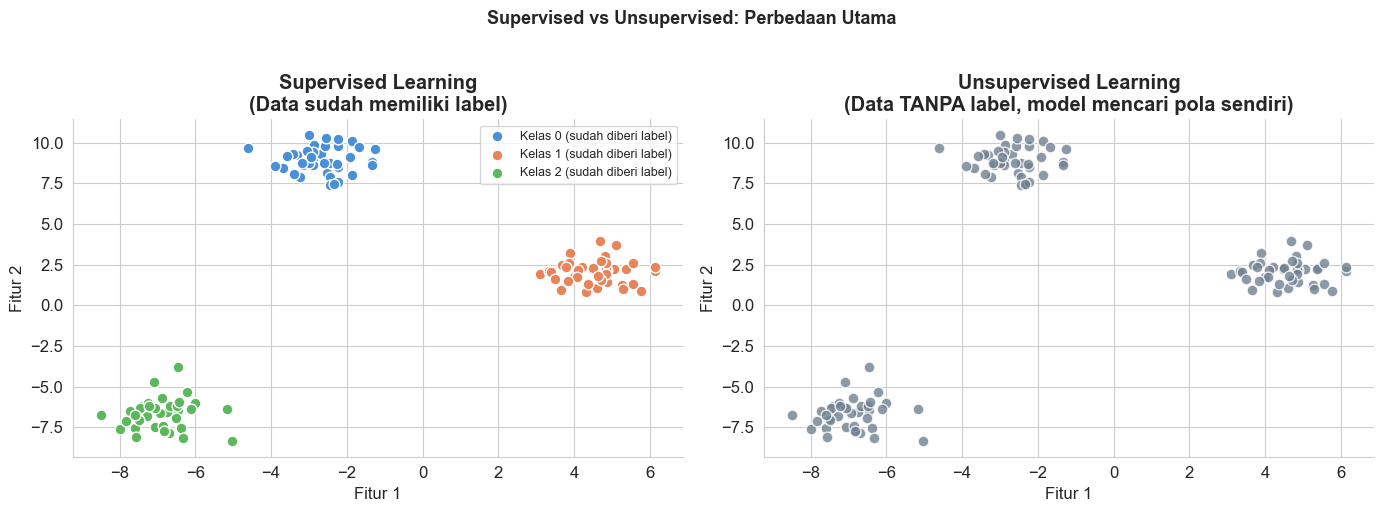

In [2]:
# Visualisasi perbedaan Supervised vs Unsupervised
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

np.random.seed(42)
X, y = make_blobs(n_samples=120, centers=3, cluster_std=0.8, random_state=42)

# Panel kiri: Supervised (ada label)
palette_sup = {0: '#4A90D9', 1: '#E8835A', 2: '#5CB85C'}
for cls in [0, 1, 2]:
    mask = y == cls
    axes[0].scatter(X[mask, 0], X[mask, 1],
                    color=palette_sup[cls], s=60, edgecolors='white',
                    label=f'Kelas {cls} (sudah diberi label)')
axes[0].set_title('Supervised Learning\n(Data sudah memiliki label)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Fitur 1'); axes[0].set_ylabel('Fitur 2')

# Panel kanan: Unsupervised (tanpa label)
axes[1].scatter(X[:, 0], X[:, 1], color='slategray', s=60,
                edgecolors='white', alpha=0.8)
axes[1].set_title('Unsupervised Learning\n(Data TANPA label, model mencari pola sendiri)',
                  fontweight='bold')
axes[1].set_xlabel('Fitur 1'); axes[1].set_ylabel('Fitur 2')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Supervised vs Unsupervised: Perbedaan Utama',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---

## 2. Pengantar Reinforcement Learning

Selain supervised dan unsupervised learning, ada paradigma ketiga yang
cara belajarnya paling berbeda: **Reinforcement Learning (RL)**.

### Analogi: Melatih Anjing

Bayangkan kamu melatih anjing untuk duduk.
- Jika anjing duduk saat diperintah, kamu beri **hadiah** (reward).
- Jika anjing tidak duduk, kamu tidak memberi hadiah.

Anjing belajar: "tindakan apa yang perlu saya lakukan untuk mendapat hadiah maksimal?"

Reinforcement Learning bekerja persis seperti ini.

### Komponen Utama RL

```
              Lingkungan (Environment)
                    |
          Keadaan saat ini (State)
                    |
                    v
              +----------+
              |  Agent   |  <-- Model/AI yang belajar
              +----------+
                    |
              Aksi (Action)
                    |
                    v
          Hadiah/Hukuman (Reward)
                    |
              (Kembali ke atas, siklus terus berulang)
```

| Komponen | Penjelasan | Contoh (Bermain Chess) |
|----------|-----------|------------------------|
| **Agent** | Yang mengambil keputusan | Program AI |
| **Environment** | Dunia tempat agent beroperasi | Papan catur |
| **State** | Kondisi saat ini | Posisi semua bidak |
| **Action** | Pilihan yang bisa diambil | Langkah yang mungkin |
| **Reward** | Sinyal umpan balik | +1 menang, -1 kalah, 0 lainnya |

### Contoh Aplikasi RL di Dunia Nyata

- **AlphaGo/AlphaZero** (DeepMind): Menguasai permainan Go, Chess, dan Shogi melebihi juara dunia manusia.
- **ChatGPT**: Menggunakan RLHF (Reinforcement Learning from Human Feedback) untuk belajar merespons dengan baik.
- **Robotika**: Robot belajar berjalan, mengambil objek, atau melipat pakaian.
- **Rekomendasi konten**: Platform seperti YouTube mengoptimalkan waktu tonton pengguna.
- **Trading algoritmik**: Agen belajar kapan harus beli/jual aset untuk memaksimalkan profit.

### Mengapa RL Berbeda?

RL tidak belajar dari dataset tetap. Ia belajar dari **interaksi langsung**
dengan lingkungan, sering kali melalui jutaan percobaan (trial and error).
Ini membuatnya sangat powerful tapi juga mahal secara komputasi.

> **Catatan:** RL membutuhkan bab tersendiri yang lebih dalam.
> Di notebook ini kita hanya mengenal konsep dasarnya
> sebagai pelengkap panorama paradigma machine learning.


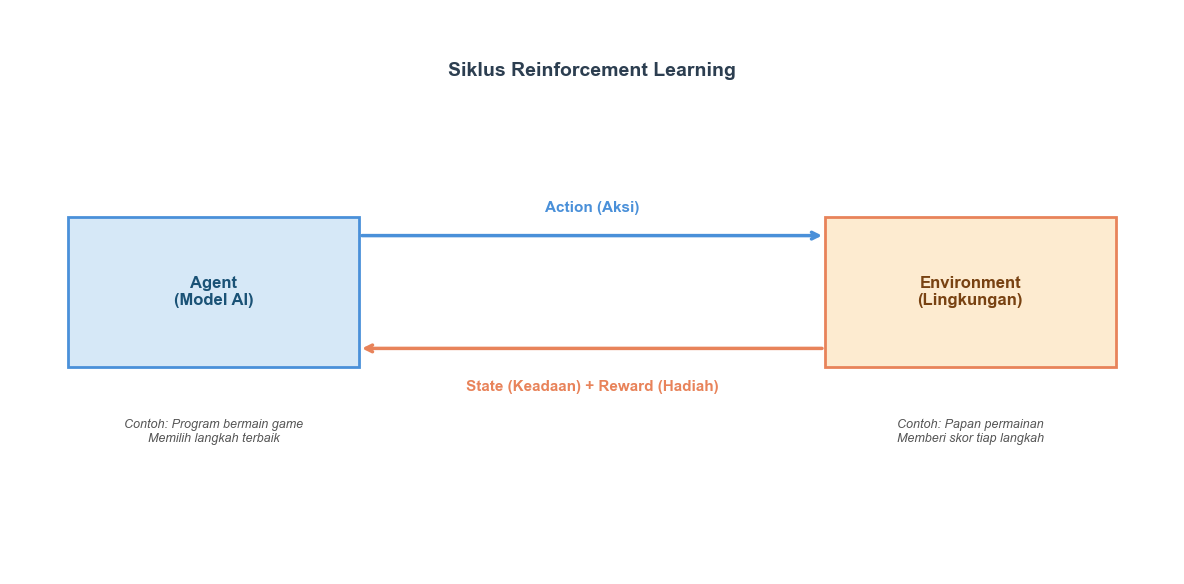

In [3]:
# Visualisasi siklus Reinforcement Learning
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')

# Kotak Agent
agent_box = plt.Rectangle((0.5, 2.2), 2.5, 1.6, linewidth=2,
                            edgecolor='#4A90D9', facecolor='#D6E8F7', zorder=3)
ax.add_patch(agent_box)
ax.text(1.75, 3.0, 'Agent\n(Model AI)', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#1a5276')

# Kotak Environment
env_box = plt.Rectangle((7.0, 2.2), 2.5, 1.6, linewidth=2,
                          edgecolor='#E8835A', facecolor='#FDEBD0', zorder=3)
ax.add_patch(env_box)
ax.text(8.25, 3.0, 'Environment\n(Lingkungan)', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#784212')

# Panah Action (atas)
ax.annotate('', xy=(7.0, 3.6), xytext=(3.0, 3.6),
            arrowprops=dict(arrowstyle='->', color='#4A90D9', lw=2.5))
ax.text(5.0, 3.85, 'Action (Aksi)', ha='center', fontsize=11,
        color='#4A90D9', fontweight='bold')

# Panah State & Reward (bawah)
ax.annotate('', xy=(3.0, 2.4), xytext=(7.0, 2.4),
            arrowprops=dict(arrowstyle='->', color='#E8835A', lw=2.5))
ax.text(5.0, 1.95, 'State (Keadaan) + Reward (Hadiah)', ha='center',
        fontsize=11, color='#E8835A', fontweight='bold')

# Label contoh
ax.text(5.0, 5.3, 'Siklus Reinforcement Learning', ha='center',
        fontsize=14, fontweight='bold', color='#2c3e50')
ax.text(1.75, 1.4, 'Contoh: Program bermain game\nMemilih langkah terbaik',
        ha='center', fontsize=9, color='#555', style='italic')
ax.text(8.25, 1.4, 'Contoh: Papan permainan\nMemberi skor tiap langkah',
        ha='center', fontsize=9, color='#555', style='italic')

plt.tight_layout()
plt.show()


---

## 3. Algoritma Clustering Populer

**Clustering** adalah tugas mengelompokkan data sehingga data dalam satu kelompok
(**cluster**) lebih mirip satu sama lain dibanding data di kelompok lain.

Kita akan menggunakan dua dataset untuk mendemonstrasikan algoritma yang berbeda:
- **Dataset blob**: Data berbentuk bola-bola rapi (cocok untuk K-Means)
- **Dataset bulan**: Data berbentuk melengkung/tidak beraturan (menantang untuk K-Means)


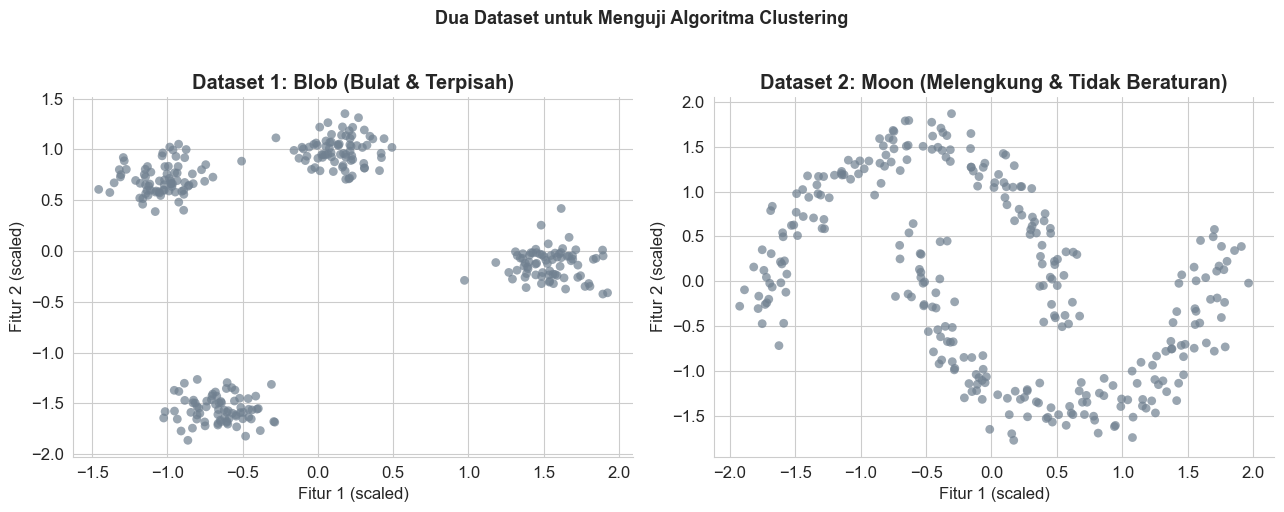

In [4]:
# Membuat dua dataset untuk perbandingan
np.random.seed(42)

# Dataset 1: Blob (bulat, terpisah jelas)
X_blob, y_blob = make_blobs(n_samples=300, centers=4,
                             cluster_std=0.9, random_state=42)

# Dataset 2: Bulan (melengkung, tidak beraturan)
X_moon, y_moon = make_moons(n_samples=300, noise=0.08, random_state=42)

# Normalisasi
scaler = StandardScaler()
X_blob_s = scaler.fit_transform(X_blob)
X_moon_s = StandardScaler().fit_transform(X_moon)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_blob_s[:, 0], X_blob_s[:, 1],
                color='slategray', s=40, alpha=0.7, edgecolors='none')
axes[0].set_title('Dataset 1: Blob (Bulat & Terpisah)', fontweight='bold')

axes[1].scatter(X_moon_s[:, 0], X_moon_s[:, 1],
                color='slategray', s=40, alpha=0.7, edgecolors='none')
axes[1].set_title('Dataset 2: Moon (Melengkung & Tidak Beraturan)', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Fitur 1 (scaled)')
    ax.set_ylabel('Fitur 2 (scaled)')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Dua Dataset untuk Menguji Algoritma Clustering',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.1 K-Means Clustering

**Intuisi:** K-Means bekerja seperti pemilihan ketua kelompok.
Tentukan dulu berapa banyak kelompok yang ingin dibuat (K), lalu algoritma:

1. Menempatkan K titik pusat (**centroid**) secara acak.
2. Setiap data "bergabung" ke centroid yang paling dekat.
3. Centroid dipindahkan ke rata-rata posisi anggotanya.
4. Langkah 2-3 diulang sampai centroid tidak bergerak lagi.

**Formula jarak (Euclidean):**

$$d(x, c) = \sqrt{\sum_{i=1}^{n} (x_i - c_i)^2}$$

**Yang dioptimalkan** (meminimalkan inertia):

$$J = \sum_{k=1}^{K} \sum_{x \in C_k} ||x - \mu_k||^2$$

Dimana $\mu_k$ adalah centroid cluster ke-$k$.

**Keterbatasan:** K-Means hanya bekerja baik untuk cluster berbentuk bulat dan berukuran mirip.


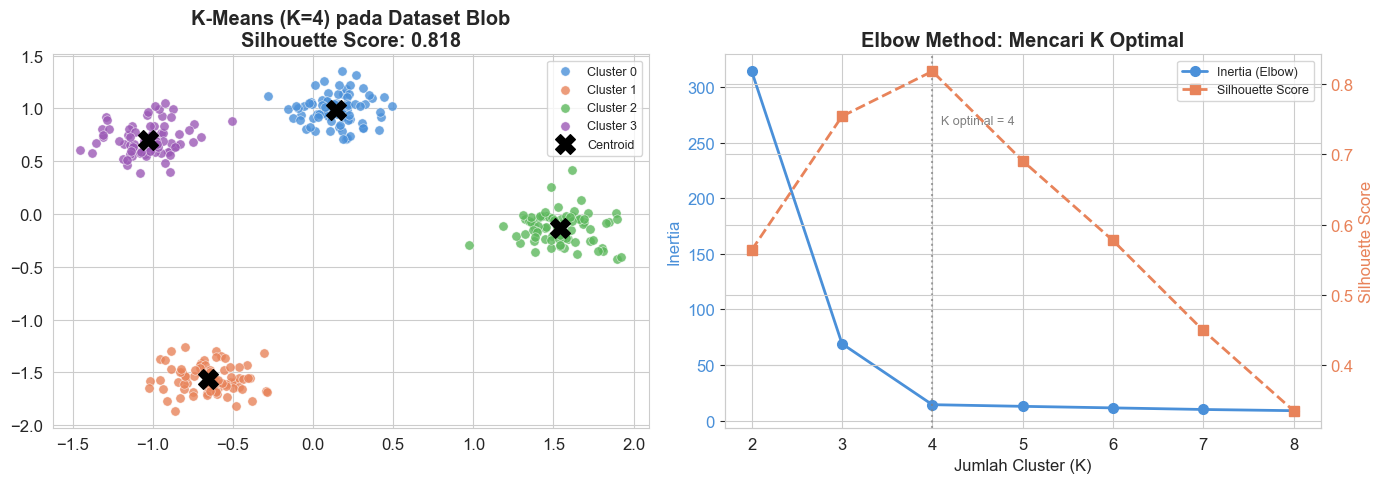

K-Means Blob - Silhouette Score: 0.8179
(Silhouette Score mendekati 1.0 = cluster sangat terpisah dengan baik)


In [5]:
# K-Means pada Dataset Blob
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_blob_s)
centroids = kmeans.cluster_centers_

palette = ['#4A90D9', '#E8835A', '#5CB85C', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hasil clustering
for k in range(4):
    mask = labels_km == k
    axes[0].scatter(X_blob_s[mask, 0], X_blob_s[mask, 1],
                    color=palette[k], s=45, alpha=0.8,
                    edgecolors='white', linewidth=0.4, label=f'Cluster {k}')
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                color='black', marker='X', s=200, zorder=5, label='Centroid')
axes[0].set_title(f'K-Means (K=4) pada Dataset Blob\nSilhouette Score: {silhouette_score(X_blob_s, labels_km):.3f}',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Mencari K optimal: Elbow Method
inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blob_s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_blob_s, km.labels_))

ax2 = axes[1]
color1, color2 = '#4A90D9', '#E8835A'
ax2.plot(K_range, inertias, 'o-', color=color1, linewidth=2, markersize=7, label='Inertia (Elbow)')
ax2.set_xlabel('Jumlah Cluster (K)')
ax2.set_ylabel('Inertia', color=color1)
ax2.tick_params(axis='y', labelcolor=color1)

ax2b = ax2.twinx()
ax2b.plot(K_range, sil_scores, 's--', color=color2, linewidth=2, markersize=7, label='Silhouette Score')
ax2b.set_ylabel('Silhouette Score', color=color2)
ax2b.tick_params(axis='y', labelcolor=color2)

ax2.set_title('Elbow Method: Mencari K Optimal', fontweight='bold')
ax2.axvline(4, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.text(4.1, max(inertias)*0.85, 'K optimal = 4', color='gray', fontsize=9)
ax2.spines[['top']].set_visible(False)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

print(f"K-Means Blob - Silhouette Score: {silhouette_score(X_blob_s, labels_km):.4f}")
print("(Silhouette Score mendekati 1.0 = cluster sangat terpisah dengan baik)")


> **Silhouette Score** mengukur seberapa baik setiap titik data cocok dengan cluster-nya
> dibanding cluster tetangga. Nilainya antara -1 hingga 1:
> - Mendekati **1**: Cluster terpisah dengan sangat baik.
> - Mendekati **0**: Data berada di batas antar cluster.
> - Mendekati **-1**: Data mungkin masuk ke cluster yang salah.


### 3.2 Hierarchical Clustering

**Intuisi:** Bayangkan kamu membangun pohon silsilah keluarga.
Hierarchical Clustering membangun sebuah **dendrogram** (pohon hierarki):

- **Agglomerative (Bottom-up):** Mulai dari setiap titik sebagai cluster sendiri,
  lalu gabungkan dua cluster yang paling dekat satu per satu, terus-menerus,
  hingga semua menjadi satu cluster besar.
- **Divisive (Top-down):** Kebalikannya, mulai dari satu cluster besar lalu pecah terus.

Pendekatan yang paling umum adalah **Agglomerative**.

**Cara membaca dendrogram:** Semakin tinggi garis horizontal tempat dua cabang bergabung,
semakin tidak mirip kedua cluster tersebut. Kita memotong dendrogram di ketinggian tertentu
untuk menentukan jumlah cluster.

**Kelebihan dibanding K-Means:** Tidak perlu menentukan K dari awal;
kita bisa melihat dendrogram dan memilih K belakangan.


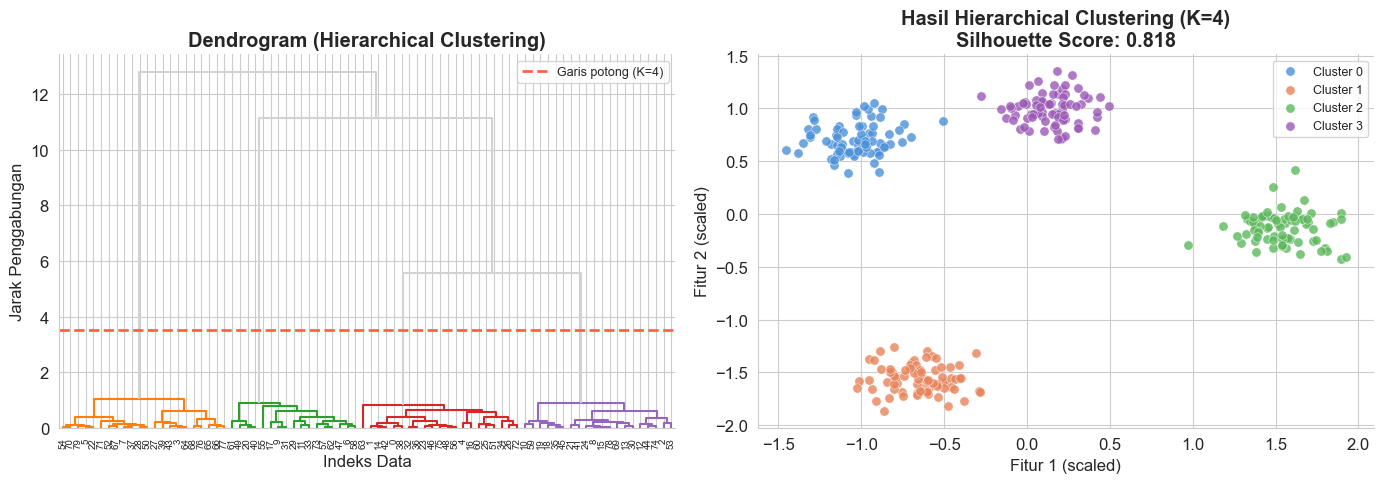

In [6]:
# Hierarchical Clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dendrogram
Z = linkage(X_blob_s[:80], method='ward')  # Pakai subset agar dendrogram tidak terlalu padat
dendrogram(Z, ax=axes[0], leaf_rotation=90, leaf_font_size=7,
           color_threshold=3.5,
           above_threshold_color='lightgray')
axes[0].axhline(y=3.5, color='tomato', linestyle='--', linewidth=2, label='Garis potong (K=4)')
axes[0].set_title('Dendrogram (Hierarchical Clustering)', fontweight='bold')
axes[0].set_xlabel('Indeks Data')
axes[0].set_ylabel('Jarak Penggabungan')
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Hasil clustering
hier = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_hier = hier.fit_predict(X_blob_s)

for k in range(4):
    mask = labels_hier == k
    axes[1].scatter(X_blob_s[mask, 0], X_blob_s[mask, 1],
                    color=palette[k], s=45, alpha=0.8,
                    edgecolors='white', linewidth=0.4, label=f'Cluster {k}')
sil_hier = silhouette_score(X_blob_s, labels_hier)
axes[1].set_title(f'Hasil Hierarchical Clustering (K=4)\nSilhouette Score: {sil_hier:.3f}',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Fitur 1 (scaled)')
axes[1].set_ylabel('Fitur 2 (scaled)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


### 3.3 DBSCAN (Density-Based Spatial Clustering)

**Intuisi:** K-Means dan Hierarchical kesulitan menangani cluster yang bentuknya tidak beraturan.
DBSCAN menggunakan pendekatan berbeda: ia mendefinisikan cluster sebagai
**wilayah padat** yang dipisahkan oleh wilayah jarang.

Bayangkan kerumunan orang di pusat perbelanjaan. DBSCAN bisa menemukan
"kelompok kerumunan" yang bentuknya tidak perlu bulat, dan menandai
orang-orang yang berdiri sendiri sebagai **outlier (noise)**.

**Dua parameter kunci:**
- **eps** ($\varepsilon$): Radius tetangga. Seberapa jauh dua titik masih dianggap "dekat"?
- **min_samples**: Minimal berapa titik dalam radius eps agar sebuah area disebut "padat"?

**Tiga jenis titik dalam DBSCAN:**

| Tipe | Penjelasan |
|------|-----------|
| **Core Point** | Memiliki minimal `min_samples` tetangga dalam radius `eps` |
| **Border Point** | Dalam radius `eps` dari core point, tapi tidak cukup tetangga |
| **Noise/Outlier** | Tidak termasuk cluster mana pun |

**Kelebihan utama:** Tidak perlu menentukan K, bisa menemukan cluster berbentuk sembarang,
dan otomatis mendeteksi outlier.


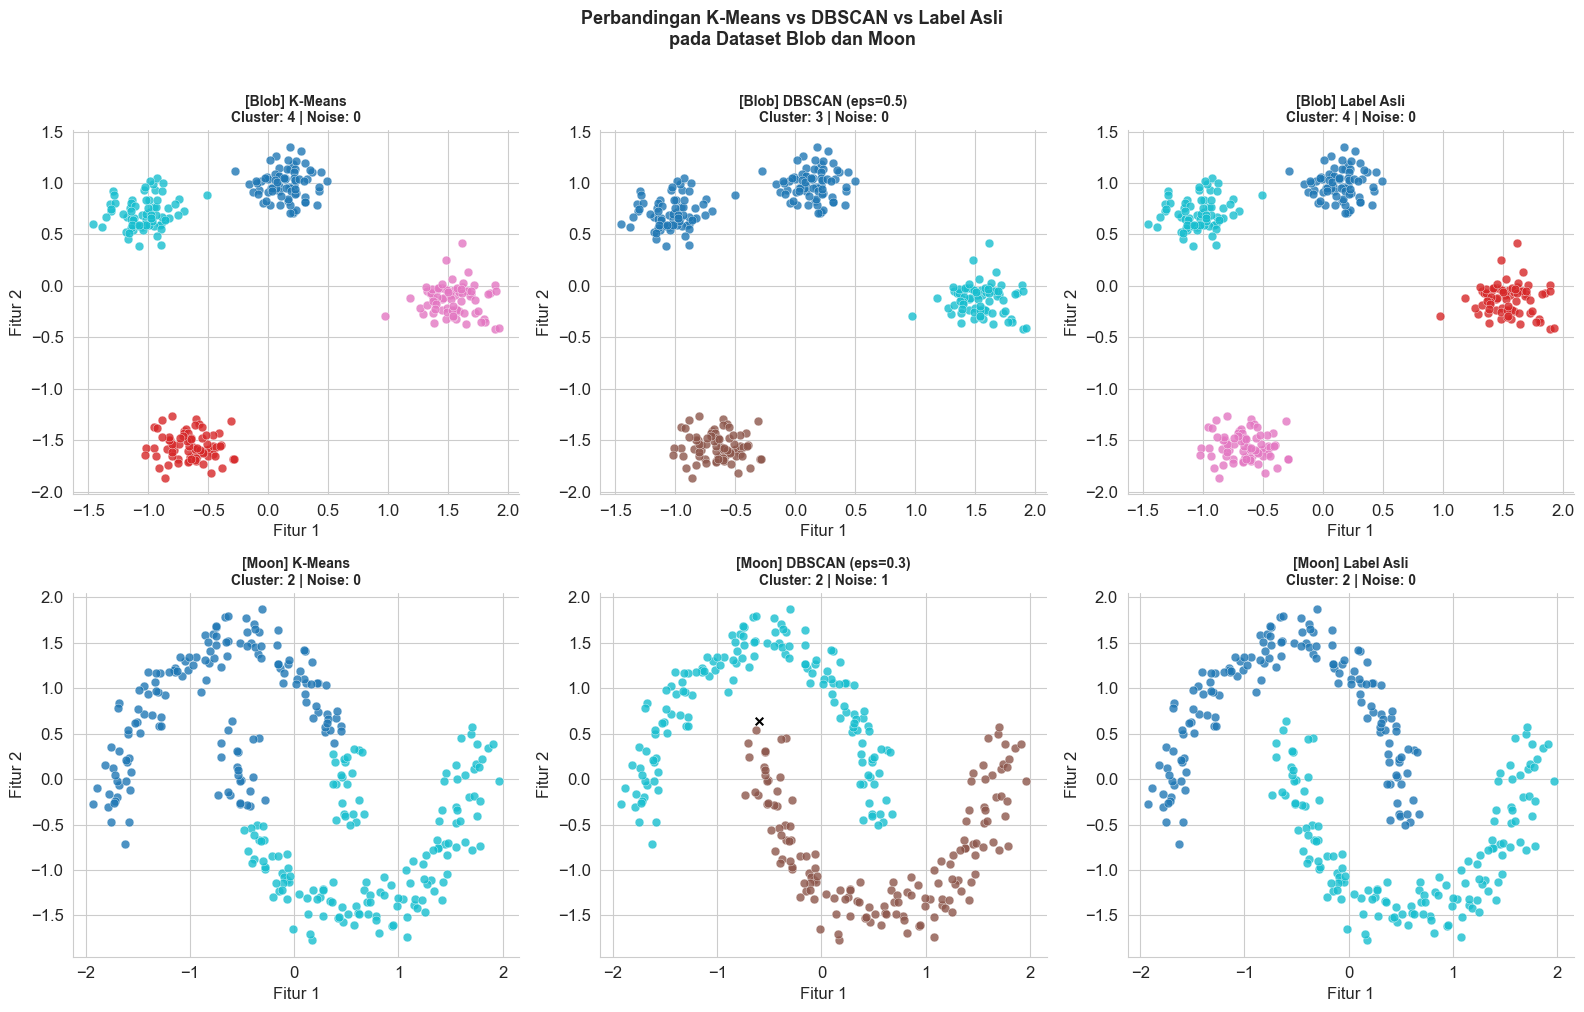

In [7]:
# DBSCAN: perbandingan di dataset Blob dan Moon
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

datasets = [('Blob', X_blob_s, y_blob), ('Moon', X_moon_s, y_moon)]
configs = [
    ('K-Means (K=2)',   None,  None),
    ('DBSCAN',          None,  None),
    ('Label Asli',      None,  None),
]

for row, (ds_name, X_ds, y_ds) in enumerate(datasets):
    # K-Means
    n_true = len(np.unique(y_ds))
    km_ds = KMeans(n_clusters=n_true, random_state=42, n_init=10)
    lbl_km = km_ds.fit_predict(X_ds)

    # DBSCAN
    eps_val = 0.3 if ds_name == 'Moon' else 0.5
    db = DBSCAN(eps=eps_val, min_samples=8)
    lbl_db = db.fit_predict(X_ds)

    for col, (labels, title) in enumerate([
        (lbl_km, f'K-Means'),
        (lbl_db, f'DBSCAN (eps={eps_val})'),
        (y_ds,   f'Label Asli'),
    ]):
        ax = axes[row][col]
        unique_labels = np.unique(labels)
        cmap = plt.cm.get_cmap('tab10', len(unique_labels))

        for i, lbl in enumerate(unique_labels):
            mask = labels == lbl
            if lbl == -1:
                ax.scatter(X_ds[mask, 0], X_ds[mask, 1],
                           color='black', s=30, marker='x',
                           linewidths=1.5, label='Noise/Outlier', zorder=5)
            else:
                ax.scatter(X_ds[mask, 0], X_ds[mask, 1],
                           color=cmap(i), s=40, alpha=0.8,
                           edgecolors='white', linewidth=0.3,
                           label=f'Cluster {lbl}')
        noise_count = np.sum(labels == -1)
        n_clusters = len([l for l in unique_labels if l != -1])
        ax.set_title(f'[{ds_name}] {title}\nCluster: {n_clusters} | Noise: {noise_count}',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Fitur 1'); ax.set_ylabel('Fitur 2')
        ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Perbandingan K-Means vs DBSCAN vs Label Asli\npada Dataset Blob dan Moon',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.4 Use Case dan Perbandingan Algoritma Clustering

| Algoritma | Kelebihan | Keterbatasan | Gunakan Saat... |
|-----------|-----------|-------------|-----------------|
| **K-Means** | Cepat, mudah diinterpretasi, skalabel untuk data besar | Perlu tentukan K, hanya untuk cluster bulat | Segmentasi pelanggan, kompresi warna gambar |
| **Hierarchical** | Tidak perlu tentukan K dari awal, menghasilkan dendrogram | Lambat untuk data besar (O(n^3)) | Data kecil, analisis filogenetik, analisis dokumen |
| **DBSCAN** | Tidak perlu K, bisa temukan bentuk sembarang, deteksi outlier | Sensitif terhadap eps dan min_samples | Deteksi anomali, analisis data geospasial, data dengan noise tinggi |


In [8]:
# Ringkasan performa ketiga algoritma pada dataset blob
results = []
for name, labels in [
    ('K-Means (K=4)',       KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_blob_s)),
    ('Hierarchical (K=4)',  AgglomerativeClustering(n_clusters=4).fit_predict(X_blob_s)),
    ('DBSCAN',              DBSCAN(eps=0.5, min_samples=8).fit_predict(X_blob_s)),
]:
    valid = labels[labels != -1]
    X_valid = X_blob_s[labels != -1]
    n_clusters = len(set(valid))
    n_noise = np.sum(labels == -1)
    sil = silhouette_score(X_valid, valid) if n_clusters > 1 else float('nan')
    results.append({'Algoritma': name, 'Jumlah Cluster': n_clusters,
                    'Noise Points': n_noise, 'Silhouette Score': f'{sil:.4f}'})

df_res = pd.DataFrame(results)
print("Ringkasan Performa pada Dataset Blob:")
print(df_res.to_string(index=False))


Ringkasan Performa pada Dataset Blob:
         Algoritma  Jumlah Cluster  Noise Points Silhouette Score
     K-Means (K=4)               4             0           0.8179
Hierarchical (K=4)               4             0           0.8179
            DBSCAN               3             0           0.7539


---

## 4. Dimensionality Reduction (Pengurangan Dimensi)

### Mengapa Ini Penting?

Data di dunia nyata sering kali memiliki **puluhan atau ratusan fitur**.
Ini menciptakan dua masalah besar:

1. **Curse of Dimensionality:** Semakin banyak fitur, data menjadi semakin "jarang"
   di ruang fitur, membuat algoritma ML sulit belajar.
2. **Visualisasi:** Kita tidak bisa memvisualisasikan data berdimensi tinggi secara langsung.

**Dimensionality reduction** memampatkan banyak fitur menjadi lebih sedikit
(biasanya 2 atau 3) tanpa kehilangan terlalu banyak informasi.

```
Data asli: 100 fitur    -->    Reduksi    -->    2 fitur (bisa divisualisasikan)
[f1, f2, f3, ..., f100]  -->  Algoritma  -->    [komponen_1, komponen_2]
```

Kita akan menggunakan dataset **Iris** (4 fitur) sebagai contoh.


In [9]:
# Memuat dataset Iris sebagai data berdimensi lebih tinggi
iris = load_iris()
X_iris = iris.data      # 4 fitur
y_iris = iris.target
target_names = iris.target_names

print("Dataset Iris:")
print(f"  Jumlah data  : {X_iris.shape[0]}")
print(f"  Jumlah fitur : {X_iris.shape[1]}")
print(f"  Nama fitur   : {list(iris.feature_names)}")
print(f"  Nama kelas   : {list(target_names)}")
print(f"\nTantangan: Bagaimana memvisualisasikan 4 dimensi sekaligus?")
print("Solusi: Kurangi menjadi 2 dimensi menggunakan PCA atau t-SNE!")


Dataset Iris:
  Jumlah data  : 150
  Jumlah fitur : 4
  Nama fitur   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Nama kelas   : ['setosa', 'versicolor', 'virginica']

Tantangan: Bagaimana memvisualisasikan 4 dimensi sekaligus?
Solusi: Kurangi menjadi 2 dimensi menggunakan PCA atau t-SNE!


### 4.1 PCA (Principal Component Analysis)

**Intuisi:** Bayangkan kamu punya data 3 dimensi (titik-titik mengambang di ruang).
PCA mencari **arah (komponen) yang merangkum variansi terbesar** dalam data,
lalu memproyeksikan data ke arah tersebut.

Analogi lebih sederhana: bayangkan kamu memotret sebuah patung dari berbagai sudut.
PCA memilih **sudut terbaik** yang menampilkan paling banyak detail patung tersebut.

**Dua konsep kunci:**
- **Principal Component (PC):** Arah baru yang merangkum variansi terbesar.
- **Explained Variance:** Berapa persen informasi asli yang dipertahankan oleh setiap PC.

**Formula PC pertama:**

$$PC_1 = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

Dimana $w$ adalah bobot (loadings) yang dipilih agar variansi di arah ini maksimal.

**Sifat PCA:** Linier dan deterministik. Hasilnya selalu sama untuk data yang sama.

**Catatan penting:** PCA tidak menjamin bahwa kelas yang berbeda akan terpisah secara visual.
Ia hanya mempertahankan variansi, bukan informasi tentang kelas.


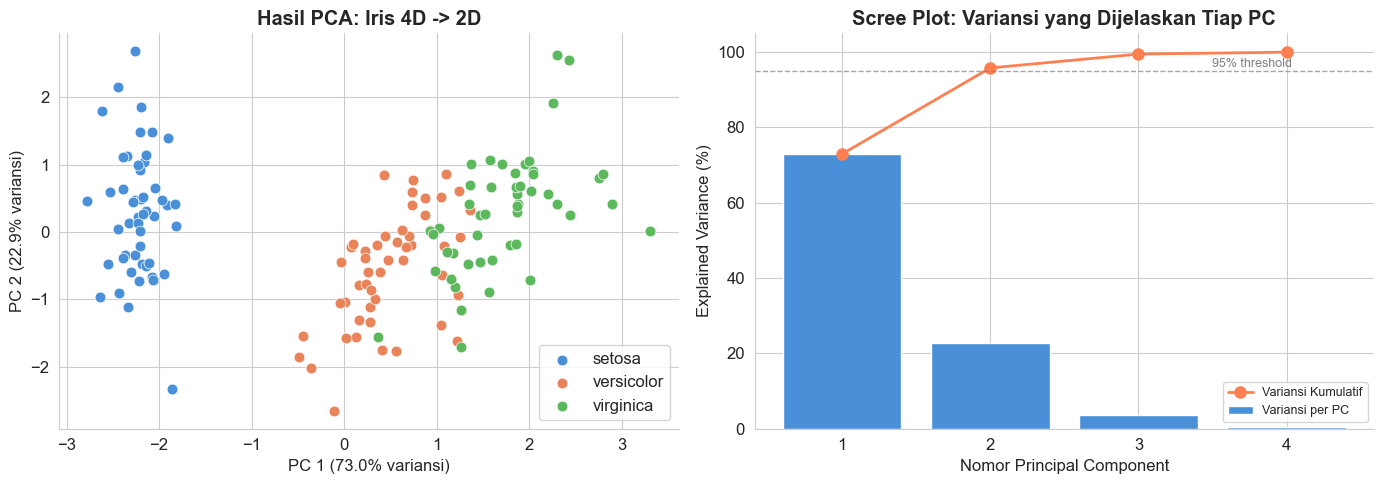

Total variansi yang dipertahankan oleh 2 PC: 95.8%
Artinya: dengan hanya 2 fitur (dari 4), kita mempertahankan 96% informasi asli.


In [10]:
# Normalisasi data
scaler_iris = StandardScaler()
X_iris_s = scaler_iris.fit_transform(X_iris)

# PCA ke 2 komponen
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_iris_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot hasil PCA
palette_iris = ['#4A90D9', '#E8835A', '#5CB85C']
for i, name in enumerate(target_names):
    mask = y_iris == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette_iris[i], label=name,
                    s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)')
axes[0].set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)')
axes[0].set_title('Hasil PCA: Iris 4D -> 2D', fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Scree Plot: Explained Variance
pca_full = PCA(random_state=42)
pca_full.fit(X_iris_s)
evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

axes[1].bar(range(1, len(evr)+1), evr*100, color='#4A90D9',
            edgecolor='white', label='Variansi per PC')
axes[1].plot(range(1, len(evr)+1), cumulative*100, 'o-',
             color='coral', linewidth=2, markersize=8, label='Variansi Kumulatif')
axes[1].axhline(95, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[1].text(3.5, 96, '95% threshold', color='gray', fontsize=9)
axes[1].set_xlabel('Nomor Principal Component')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title('Scree Plot: Variansi yang Dijelaskan Tiap PC', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_xticks(range(1, len(evr)+1))

plt.tight_layout()
plt.show()

total_2pc = sum(pca.explained_variance_ratio_) * 100
print(f"Total variansi yang dipertahankan oleh 2 PC: {total_2pc:.1f}%")
print(f"Artinya: dengan hanya 2 fitur (dari 4), kita mempertahankan {total_2pc:.0f}% informasi asli.")


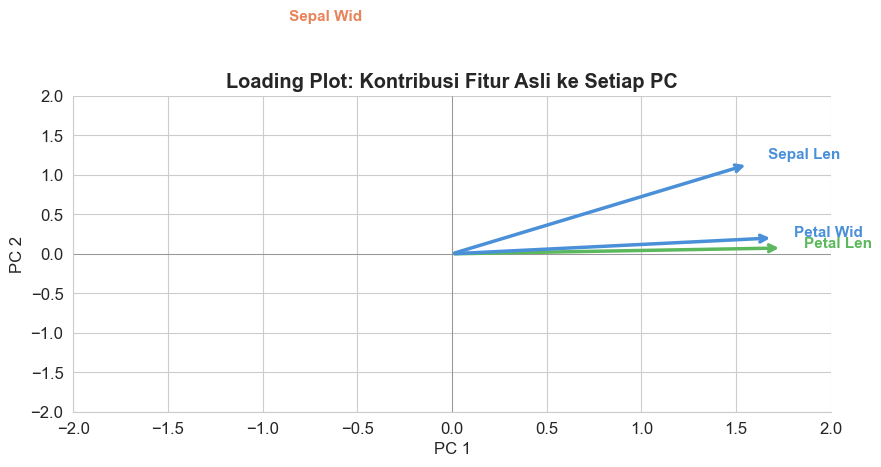

Interpretasi Loading Plot:
  - Panah panjang = fitur tersebut sangat mempengaruhi PC tersebut.
  - Panah searah = fitur berkorelasi positif.
  - Panah berlawanan arah = fitur berkorelasi negatif.


In [11]:
# Visualisasi: arti tiap PC (loading plot)
fig, ax = plt.subplots(figsize=(9, 5))

feature_names_short = ['Sepal Len', 'Sepal Wid', 'Petal Len', 'Petal Wid']
loadings = pca.components_.T

for i, (name, load) in enumerate(zip(feature_names_short, loadings)):
    ax.annotate('', xy=(load[0]*3, load[1]*3), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=palette_iris[i % 3], lw=2.5))
    ax.text(load[0]*3.2, load[1]*3.2, name, fontsize=11,
            color=palette_iris[i % 3], fontweight='bold')

ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Loading Plot: Kontribusi Fitur Asli ke Setiap PC', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Interpretasi Loading Plot:")
print("  - Panah panjang = fitur tersebut sangat mempengaruhi PC tersebut.")
print("  - Panah searah = fitur berkorelasi positif.")
print("  - Panah berlawanan arah = fitur berkorelasi negatif.")


### 4.2 t-SNE untuk Visualisasi

**Intuisi:** PCA bekerja secara linier: ia mencari kombinasi linier fitur terbaik.
Bagaimana jika pola dalam data **tidak linier**?

**t-SNE (t-distributed Stochastic Neighbor Embedding)** menggunakan pendekatan berbeda:
ia berusaha mempertahankan **hubungan ketetanggaan** data.
Jika dua titik berdekatan di ruang asli, mereka akan tetap berdekatan setelah reduksi.

**Analogi:** Bayangkan kamu memetakan posisi semua kota di Indonesia ke sebuah kertas 2D.
t-SNE berusaha menjaga agar kota-kota yang dekat satu sama lain di dunia nyata
juga berdekatan di peta kertas.

**Parameter kunci:**
- **perplexity**: Mengontrol berapa banyak "tetangga" yang dipertimbangkan tiap titik.
  Nilai tipikal: 5-50. Semakin besar, cluster terlihat lebih global.

**Kapan pakai PCA vs t-SNE?**

| | PCA | t-SNE |
|--|-----|-------|
| Tujuan utama | Reduksi fitur untuk ML | Visualisasi data saja |
| Kecepatan | Sangat cepat | Lambat untuk data besar |
| Deterministik | Ya | Tidak (ada elemen acak) |
| Interpretasi komponen | Bisa | Tidak mudah |
| Data besar (>10.000 baris) | Ya | Tidak disarankan |


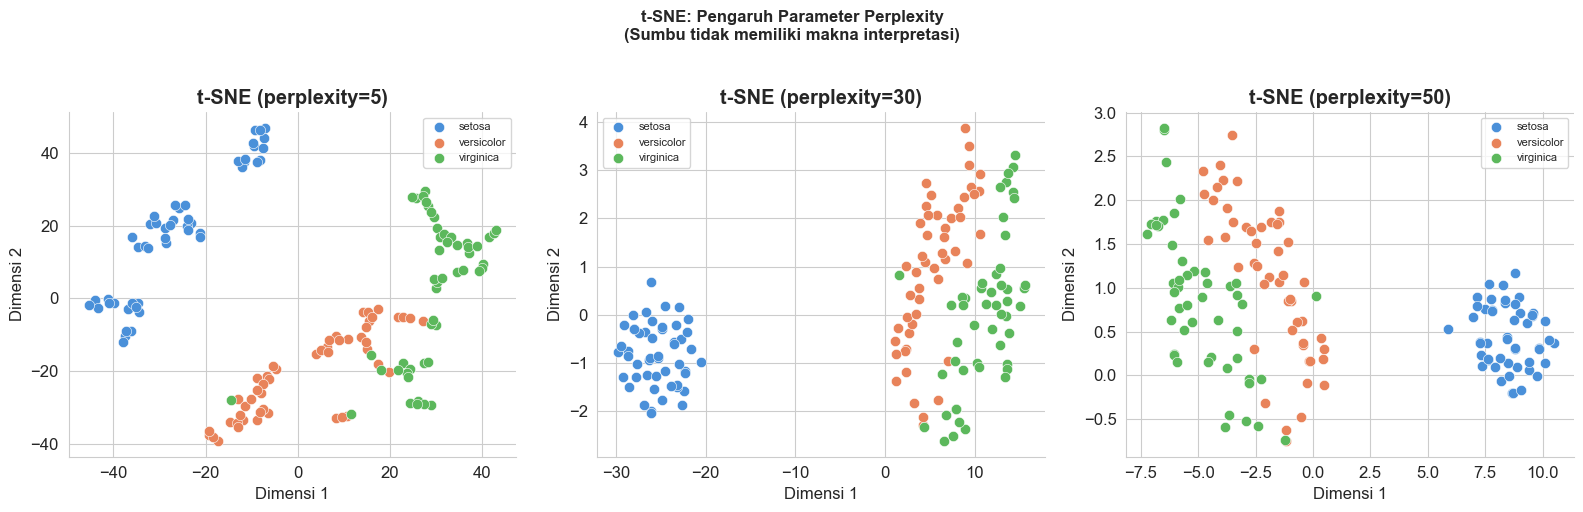

In [12]:
# t-SNE dengan berbagai nilai perplexity
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_iris_s)

    for i, name in enumerate(target_names):
        mask = y_iris == i
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   color=palette_iris[i], label=name,
                   s=55, edgecolors='white', linewidth=0.4)
    ax.set_title(f't-SNE (perplexity={perp})', fontweight='bold')
    ax.set_xlabel('Dimensi 1'); ax.set_ylabel('Dimensi 2')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('t-SNE: Pengaruh Parameter Perplexity\n(Sumbu tidak memiliki makna interpretasi)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


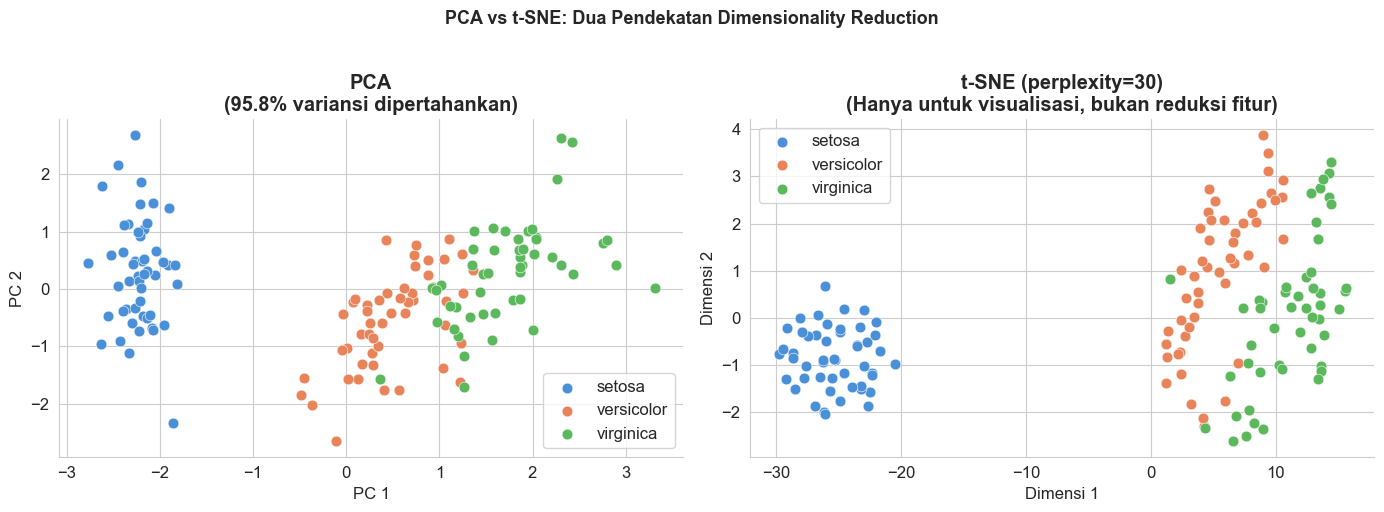

Perhatikan:
  PCA    : Cluster Setosa terpisah jelas, Versicolor dan Virginica sedikit tumpang tindih.
  t-SNE  : Ketiga kelas terpisah lebih jelas, tapi posisi/jarak antar cluster tidak bermakna.


In [13]:
# Perbandingan langsung PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
for i, name in enumerate(target_names):
    mask = y_iris == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette_iris[i], label=name,
                    s=60, edgecolors='white', linewidth=0.4)
axes[0].set_title(f'PCA\n({pca.explained_variance_ratio_.sum()*100:.1f}% variansi dipertahankan)',
                  fontweight='bold')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# t-SNE (perplexity=30)
tsne_best = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_best = tsne_best.fit_transform(X_iris_s)
for i, name in enumerate(target_names):
    mask = y_iris == i
    axes[1].scatter(X_tsne_best[mask, 0], X_tsne_best[mask, 1],
                    color=palette_iris[i], label=name,
                    s=60, edgecolors='white', linewidth=0.4)
axes[1].set_title('t-SNE (perplexity=30)\n(Hanya untuk visualisasi, bukan reduksi fitur)',
                  fontweight='bold')
axes[1].set_xlabel('Dimensi 1'); axes[1].set_ylabel('Dimensi 2')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('PCA vs t-SNE: Dua Pendekatan Dimensionality Reduction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Perhatikan:")
print("  PCA    : Cluster Setosa terpisah jelas, Versicolor dan Virginica sedikit tumpang tindih.")
print("  t-SNE  : Ketiga kelas terpisah lebih jelas, tapi posisi/jarak antar cluster tidak bermakna.")


---

## 5. Kapan Menggunakan Supervised vs Unsupervised?

Ini adalah pertanyaan yang paling sering muncul dari praktisi ML pemula.
Jawabannya bergantung pada beberapa faktor kunci.


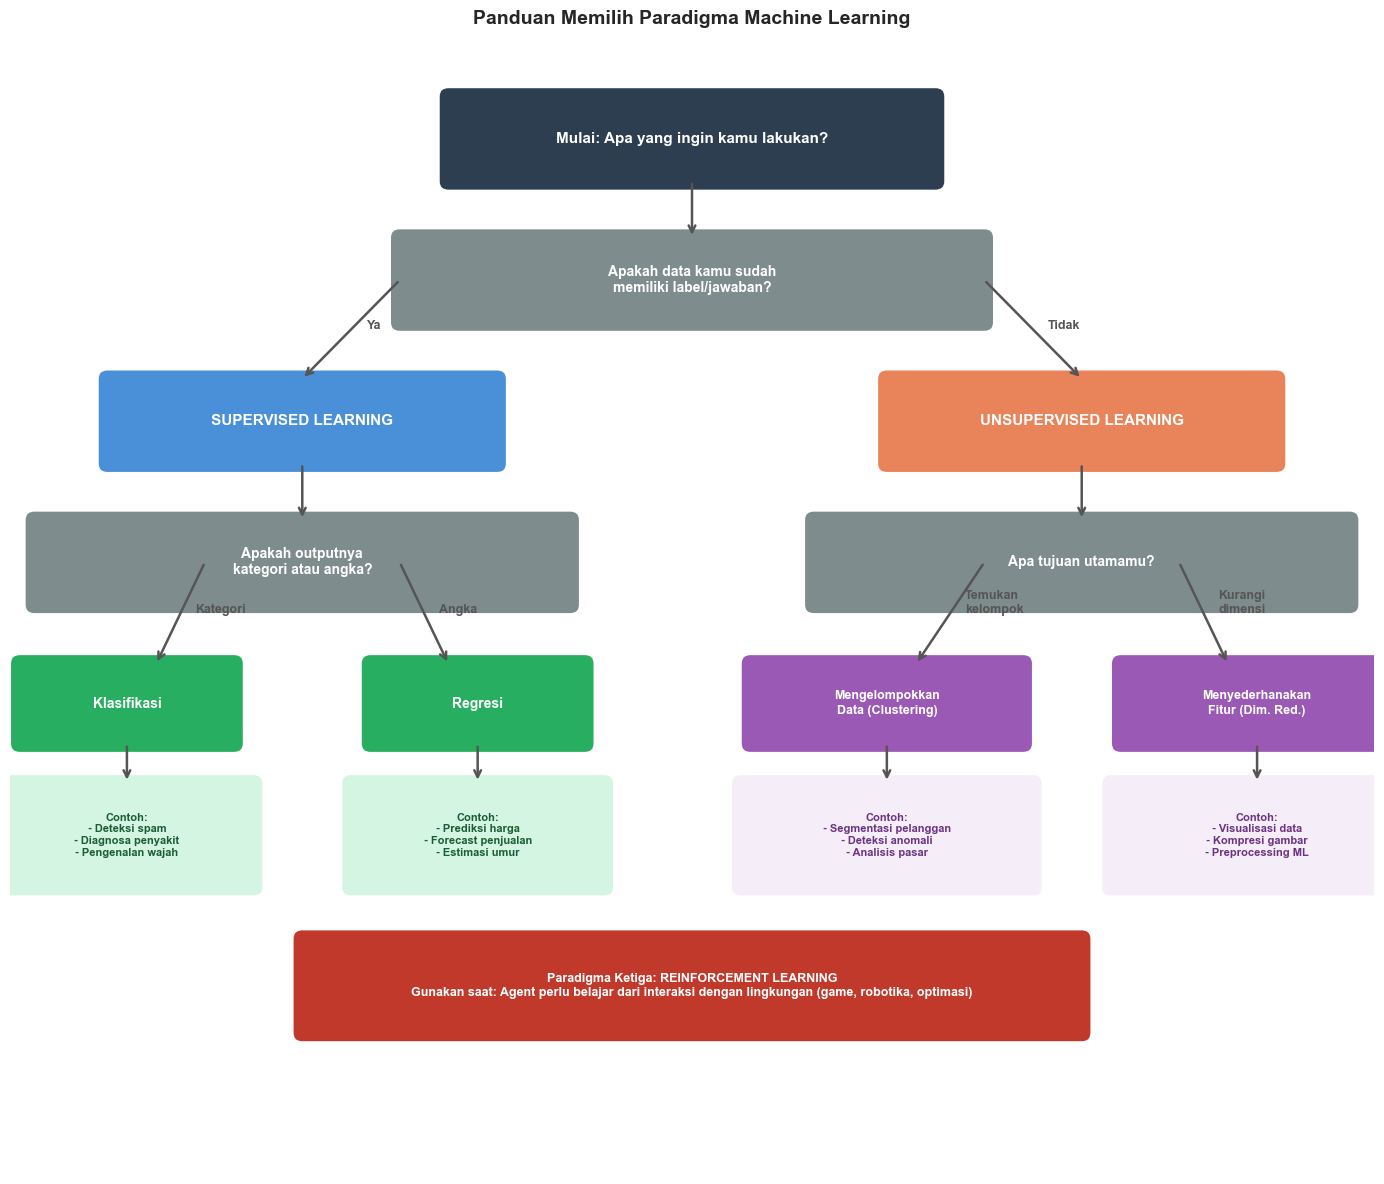

In [14]:
# Flowchart pemilihan paradigma ML
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_xlim(0, 14); ax.set_ylim(0, 12); ax.axis('off')

def draw_box(ax, x, y, w, h, text, color, text_color='white', fontsize=10, style='round,pad=0.1'):
    box = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                   boxstyle=style,
                                   facecolor=color, edgecolor='white',
                                   linewidth=1.5, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=text_color, zorder=4,
            multialignment='center', wrap=True)

def arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=9, color=color, fontweight='bold')

# Node utama
draw_box(ax, 7, 11, 5, 0.9, 'Mulai: Apa yang ingin kamu lakukan?',
         '#2c3e50', fontsize=11)

# Pertanyaan 1
draw_box(ax, 7, 9.5, 6, 0.9,
         'Apakah data kamu sudah\nmemiliki label/jawaban?',
         '#7f8c8d', fontsize=10)
arrow(ax, 7, 10.55, 7, 9.95)

# Ya -> Supervised
draw_box(ax, 3, 8, 4, 0.9, 'SUPERVISED LEARNING', '#4A90D9', fontsize=11)
arrow(ax, 4, 9.5, 3, 8.45, 'Ya')

# Tidak -> Unsupervised
draw_box(ax, 11, 8, 4, 0.9, 'UNSUPERVISED LEARNING', '#E8835A', fontsize=11)
arrow(ax, 10, 9.5, 11, 8.45, 'Tidak')

# Supervised -> Klasifikasi / Regresi
draw_box(ax, 3, 6.5, 5.5, 0.9,
         'Apakah outputnya\nkategori atau angka?', '#7f8c8d', fontsize=10)
arrow(ax, 3, 7.55, 3, 6.95)

draw_box(ax, 1.2, 5.0, 2.2, 0.85, 'Klasifikasi', '#27ae60', fontsize=10)
arrow(ax, 2.0, 6.5, 1.5, 5.42, 'Kategori')

draw_box(ax, 4.8, 5.0, 2.2, 0.85, 'Regresi', '#27ae60', fontsize=10)
arrow(ax, 4.0, 6.5, 4.5, 5.42, 'Angka')

# Contoh Supervised
draw_box(ax, 1.2, 3.6, 2.6, 1.1,
         'Contoh:\n- Deteksi spam\n- Diagnosa penyakit\n- Pengenalan wajah',
         '#d5f5e3', '#1a5e35', fontsize=8, style='round,pad=0.1')
arrow(ax, 1.2, 4.57, 1.2, 4.16)

draw_box(ax, 4.8, 3.6, 2.6, 1.1,
         'Contoh:\n- Prediksi harga\n- Forecast penjualan\n- Estimasi umur',
         '#d5f5e3', '#1a5e35', fontsize=8, style='round,pad=0.1')
arrow(ax, 4.8, 4.57, 4.8, 4.16)

# Unsupervised -> Clustering / Dim Red
draw_box(ax, 11, 6.5, 5.5, 0.9,
         'Apa tujuan utamamu?', '#7f8c8d', fontsize=10)
arrow(ax, 11, 7.55, 11, 6.95)

draw_box(ax, 9, 5.0, 2.8, 0.85, 'Mengelompokkan\nData (Clustering)', '#9b59b6', fontsize=9)
arrow(ax, 10, 6.5, 9.3, 5.42, 'Temukan\nkelompok')

draw_box(ax, 12.8, 5.0, 2.8, 0.85, 'Menyederhanakan\nFitur (Dim. Red.)', '#9b59b6', fontsize=9)
arrow(ax, 12.0, 6.5, 12.5, 5.42, 'Kurangi\ndimensi')

# Contoh Unsupervised
draw_box(ax, 9, 3.6, 3.0, 1.1,
         'Contoh:\n- Segmentasi pelanggan\n- Deteksi anomali\n- Analisis pasar',
         '#f5eef8', '#6c3483', fontsize=8, style='round,pad=0.1')
arrow(ax, 9, 4.57, 9, 4.16)

draw_box(ax, 12.8, 3.6, 3.0, 1.1,
         'Contoh:\n- Visualisasi data\n- Kompresi gambar\n- Preprocessing ML',
         '#f5eef8', '#6c3483', fontsize=8, style='round,pad=0.1')
arrow(ax, 12.8, 4.57, 12.8, 4.16)

# RL note
draw_box(ax, 7, 2.0, 8, 1.0,
         'Paradigma Ketiga: REINFORCEMENT LEARNING\n'
         'Gunakan saat: Agent perlu belajar dari interaksi dengan lingkungan (game, robotika, optimasi)',
         '#c0392b', fontsize=9)

ax.set_title('Panduan Memilih Paradigma Machine Learning',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### 5.2 Contoh Kasus Nyata: Supervised vs Unsupervised

Mari kita lihat satu contoh konkret untuk mempertegas perbedaannya.


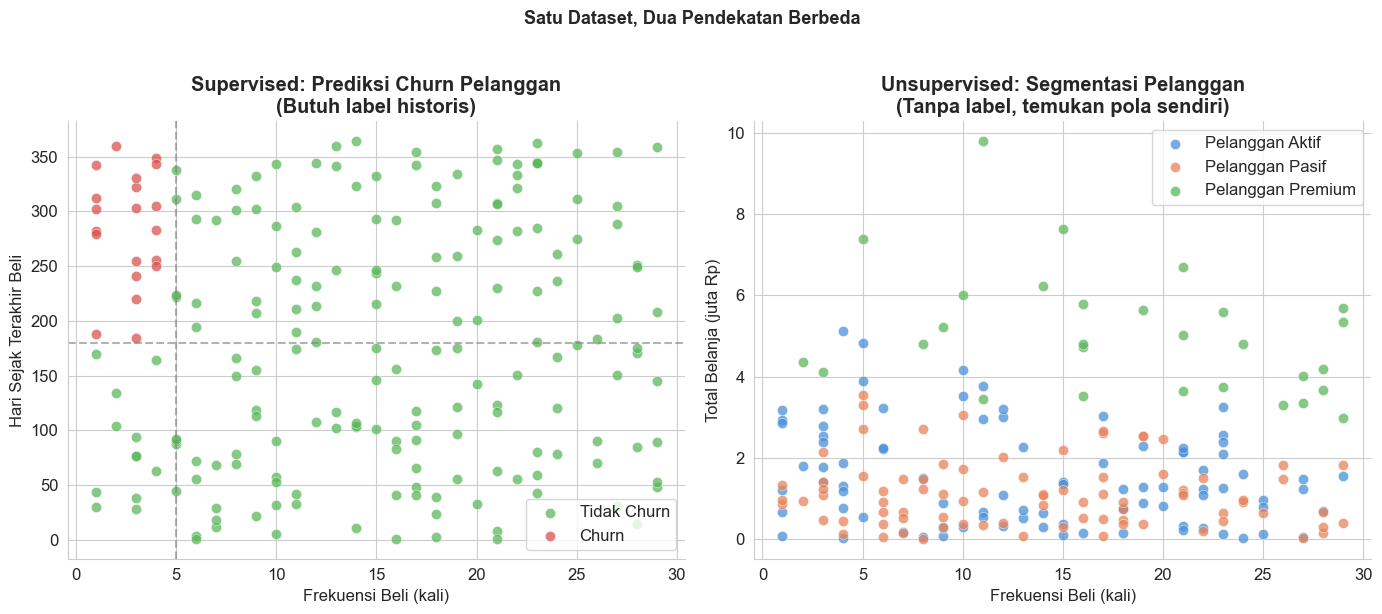

Profil Rata-rata Tiap Segmen Pelanggan (Unsupervised):
                   total_belanja_juta  frekuensi_beli  hari_sejak_terakhir
nama_segmen                                                               
Pelanggan Aktif                   1.5            13.6                292.2
Pelanggan Pasif                   1.1            13.5                 90.9
Pelanggan Premium                 5.0            18.2                132.1


In [15]:
# Contoh konkret: Analisis Pelanggan E-Commerce
np.random.seed(7)
n_cust = 200

df_cust = pd.DataFrame({
    'total_belanja_juta'  : np.round(np.random.exponential(2, n_cust), 2),
    'frekuensi_beli'      : np.random.randint(1, 30, n_cust),
    'hari_sejak_terakhir' : np.random.randint(1, 365, n_cust),
})

# ---- SKENARIO 1: Supervised ----
# "Apakah pelanggan ini akan churn (berhenti)?"
# -> Butuh label historis (churn atau tidak)
df_cust['churn'] = (
    (df_cust['hari_sejak_terakhir'] > 180) &
    (df_cust['frekuensi_beli'] < 5)
).astype(int)

# ---- SKENARIO 2: Unsupervised ----
# "Siapa saja segmen pelanggan kita?"
# -> Tidak butuh label, temukan sendiri
X_cust = StandardScaler().fit_transform(
    df_cust[['total_belanja_juta', 'frekuensi_beli', 'hari_sejak_terakhir']]
)
km_cust = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cust['segmen'] = km_cust.fit_predict(X_cust)
seg_labels = {0: 'Pelanggan Aktif', 1: 'Pelanggan Pasif', 2: 'Pelanggan Premium'}
df_cust['nama_segmen'] = df_cust['segmen'].map(seg_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel Supervised: Prediksi Churn
colors_churn = {0: '#5CB85C', 1: '#d9534f'}
for c in [0, 1]:
    mask = df_cust['churn'] == c
    axes[0].scatter(df_cust.loc[mask, 'frekuensi_beli'],
                    df_cust.loc[mask, 'hari_sejak_terakhir'],
                    color=colors_churn[c], s=55, alpha=0.75,
                    edgecolors='white', linewidth=0.4,
                    label='Churn' if c == 1 else 'Tidak Churn')
axes[0].axvline(5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
axes[0].axhline(180, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
axes[0].set_xlabel('Frekuensi Beli (kali)')
axes[0].set_ylabel('Hari Sejak Terakhir Beli')
axes[0].set_title('Supervised: Prediksi Churn Pelanggan\n(Butuh label historis)', fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Panel Unsupervised: Segmentasi
colors_seg = {'Pelanggan Aktif': '#4A90D9', 'Pelanggan Pasif': '#E8835A', 'Pelanggan Premium': '#5CB85C'}
for seg, color in colors_seg.items():
    mask = df_cust['nama_segmen'] == seg
    axes[1].scatter(df_cust.loc[mask, 'frekuensi_beli'],
                    df_cust.loc[mask, 'total_belanja_juta'],
                    color=color, s=55, alpha=0.75,
                    edgecolors='white', linewidth=0.4, label=seg)
axes[1].set_xlabel('Frekuensi Beli (kali)')
axes[1].set_ylabel('Total Belanja (juta Rp)')
axes[1].set_title('Unsupervised: Segmentasi Pelanggan\n(Tanpa label, temukan pola sendiri)',
                  fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Satu Dataset, Dua Pendekatan Berbeda',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ringkasan segmen
print("Profil Rata-rata Tiap Segmen Pelanggan (Unsupervised):")
print(df_cust.groupby('nama_segmen')[
    ['total_belanja_juta', 'frekuensi_beli', 'hari_sejak_terakhir']
].mean().round(1).to_string())


### Ringkasan: Kapan Menggunakan Paradigma yang Mana?

| Kondisi | Paradigma |
|---------|-----------|
| Punya data berlabel, ingin prediksi kelas | Supervised - Klasifikasi |
| Punya data berlabel, ingin prediksi angka | Supervised - Regresi |
| Tidak punya label, ingin temukan kelompok | Unsupervised - Clustering |
| Data berdimensi tinggi, ingin visualisasi atau preprocessing | Unsupervised - Dim. Reduction |
| Agent harus belajar dari trial-error di lingkungan dinamis | Reinforcement Learning |
| Punya sedikit data berlabel dan banyak data tanpa label | Semi-supervised Learning* |

> *Semi-supervised Learning adalah pendekatan hybrid yang menggabungkan sedikit data berlabel
> dengan banyak data tanpa label. Ini dibahas di topik lanjutan.


---

## Rangkuman

**Unsupervised Learning**
- Belajar dari data tanpa label dengan menemukan pola tersembunyi.
- Dua tugas utama: *Clustering* (mengelompokkan) dan *Dimensionality Reduction* (meringkas fitur).

**Reinforcement Learning**
- Paradigma ketiga di mana agent belajar lewat interaksi dan umpan balik (reward).
- Cocok untuk masalah sekuensial dan lingkungan dinamis seperti game dan robotika.

**Algoritma Clustering**
- **K-Means**: Cepat dan intuitif, cocok untuk cluster berbentuk bulat.
- **Hierarchical**: Menghasilkan dendrogram, tidak perlu menentukan K lebih awal.
- **DBSCAN**: Tahan terhadap noise, bisa menangani bentuk cluster sembarang.

**Dimensionality Reduction**
- **PCA**: Linier, cepat, interpretatif, cocok untuk reduksi fitur sebelum modeling.
- **t-SNE**: Non-linier, hanya untuk visualisasi, sangat baik mengungkap struktur tersembunyi.

**Panduan Memilih Paradigma**
- Ada label + prediksi kelas/angka -> Supervised Learning.
- Tidak ada label + ingin temukan struktur -> Unsupervised Learning.
- Agent belajar dari lingkungan secara real-time -> Reinforcement Learning.

---

**Selanjutnya (Post 4):** Evaluasi Model: Metrik, Overfitting, dan Cross-Validation

*Bagaimana kita tahu apakah model yang sudah kita latih benar-benar bisa diandalkan?*
